Dua Kecepatan yang Berbeda

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ASEAN8 = ["Indonesia", "Vietnam", "Thailand", "Philippines",
          "Myanmar", "Cambodia", "Laos", "Malaysia"]
NAMA_ID = {"Indonesia": "Indonesia", "Vietnam": "Vietnam", "Thailand": "Thailand",
           "Philippines": "Filipina", "Myanmar": "Myanmar", "Cambodia": "Kamboja",
           "Laos": "Laos", "Malaysia": "Malaysia"}
WARNA_HIGHLIGHT = "#D64545"

FERT_URL = "/content/fertilizer-use-per-hectare-of-cropland.csv"

# fallback: titik 2002 & 2021 (kg/ha), tervalidasi cocok dgn dokumen
_fert_fallback = pd.DataFrame({
    "Entity": ASEAN8,
    "Year_2002": [71.2, 221.3, 83.6, 71.4, 4.0, 6.7, 9.9, 169.6],
    "Year_2021": [154.8, 266.7, 109.2, 116.0, 34.0, 44.2, 57.6, 214.0],
})

try:
    fert_raw = pd.read_csv(FERT_URL, storage_options={"User-Agent": "notebook/1.0"})
    print("[OK] Data diambil langsung dari OWID.")
except Exception as e:
    print(f"[INFO] Gagal akses OWID ({e}); pakai data cadangan.")
    fert_raw = _fert_fallback.copy()

fert_raw.head()

[INFO] Gagal akses OWID (storage_options passed with file object or non-fsspec file path); pakai data cadangan.


,Entity,Year_2002,Year_2021
0,Indonesia,71.2,154.8
1,Vietnam,221.3,266.7
2,Thailand,83.6,109.2
3,Philippines,71.4,116.0
4,Myanmar,4.0,34.0


In [2]:
value_col = [c for c in fert_raw.columns
             if ("nutrient" in c.lower() or "fertilizer" in c.lower() or "kg" in c.lower())
             and c not in ("Entity", "Code", "Year")]

if value_col and "Year_2002" not in fert_raw.columns:
    df = fert_raw[fert_raw["Entity"].isin(ASEAN8)]
    df = df[df["Year"].isin([2002, 2021])]
    pivot_fert = df.pivot(index="Entity", columns="Year", values=value_col[0])
    pivot_fert.columns = ["Year_2002", "Year_2021"]
    pivot_fert = pivot_fert.reset_index()
else:
    pivot_fert = fert_raw.copy()

pivot_fert["Perubahan_%"] = (pivot_fert["Year_2021"] / pivot_fert["Year_2002"] - 1) * 100
pivot_fert["Negara"] = pivot_fert["Entity"].map(NAMA_ID)
pivot_fert = pivot_fert.sort_values("Year_2021", ascending=False).reset_index(drop=True)

print(f"Rasio tertinggi/terendah 2021: {pivot_fert['Year_2021'].max()/pivot_fert['Year_2021'].min():.1f}x")
pivot_fert[["Negara", "Year_2002", "Year_2021", "Perubahan_%"]]

Rasio tertinggi/terendah 2021: 7.8x


,Negara,Year_2002,Year_2021,Perubahan_%
0,Vietnam,221.3,266.7,20.515138
1,Malaysia,169.6,214.0,26.179245
2,Indonesia,71.2,154.8,117.415730
3,Filipina,71.4,116.0,62.464986
4,Thailand,83.6,109.2,30.622010
5,Laos,9.9,57.6,481.818182
6,Kamboja,6.7,44.2,559.701493
7,Myanmar,4.0,34.0,750.000000


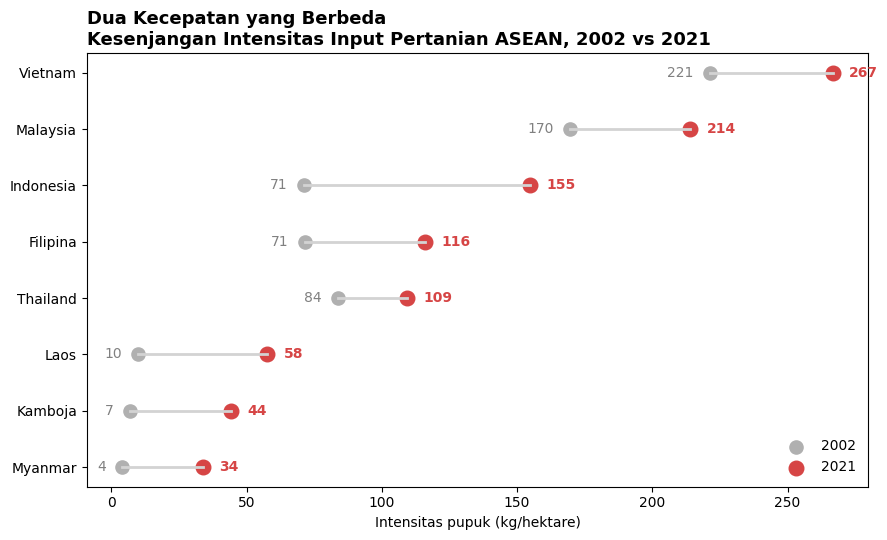

In [3]:
plot_df = pivot_fert.sort_values("Year_2021", ascending=True).reset_index(drop=True)
y_pos = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(9, 5.5))
for i, row in plot_df.iterrows():
    ax.plot([row["Year_2002"], row["Year_2021"]], [i, i], color="lightgray", linewidth=2)
ax.scatter(plot_df["Year_2002"], y_pos, color="#B0B0B0", s=90, label="2002")
ax.scatter(plot_df["Year_2021"], y_pos, color=WARNA_HIGHLIGHT, s=110, label="2021")

for i, row in plot_df.iterrows():
    ax.text(row["Year_2021"] + 6, i, f"{row['Year_2021']:.0f}", va="center", fontweight="bold", color=WARNA_HIGHLIGHT)
    ax.text(row["Year_2002"] - 6, i, f"{row['Year_2002']:.0f}", va="center", ha="right", color="gray")

ax.set_yticks(y_pos); ax.set_yticklabels(plot_df["Negara"])
ax.set_xlabel("Intensitas pupuk (kg/hektare)")
ax.set_title("Dua Kecepatan yang Berbeda\nKesenjangan Intensitas Input Pertanian ASEAN, 2002 vs 2021",
             fontsize=13, fontweight="bold", loc="left")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()